**Introduction**

This project analyzes the relationship between Bitcoin market sentiment (Fear vs Greed) and trader behavior on the Hyperliquid platform. The goal is to understand how different market sentiments influence trading performance and decision-making.

Two datasets are used in this analysis:

1. Bitcoin Fear and Greed Index dataset, which provides daily market sentiment classifications.

2. Hyperliquid historical trader dataset, which contains detailed information about trades such as account, trade size, position direction, and profit/loss.

The datasets are merged based on the trading date to examine patterns between market sentiment and trader activity, including metrics such as profit and loss (PnL), trade frequency, position size, and trading direction.

The objective of this analysis is to uncover insights that could help design better trading strategies based on market sentiment trends.

In [33]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#Load Datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

In [35]:
import pandas as pd

fear_greed_index = pd.read_csv("fear_greed_index.csv")
historical_data = pd.read_csv("historical_data.csv")

In [36]:
#Check Data
print(fear_greed_index.shape)
print(historical_data.shape)

fear_greed_index.head()
historical_data.head()

(2644, 4)
(211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [37]:
#Check Missing Values
print(sentiment.isnull().sum())
print(trader.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [38]:
#check columns
print(fear_greed_index.columns)
print(historical_data.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [58]:
#Convert Date Columns
fear_greed_index['date'] = pd.to_datetime(fear_greed_index['date'])

historical_data['Timestamp'] = pd.to_datetime(historical_data['Timestamp'])

historical_data['date'] = historical_data['Timestamp'].dt.date
fear_greed_index['date'] = fear_greed_index['date'].dt.date

In [65]:
#Merge the Datasets
df = pd.merge(historical_data, fear_greed_index, on='date', how='inner')

In [44]:
#Check dates in both datasets
print(fear_greed_index['date'].head())
print(historical_data['date'].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
0    2024-02-12
1    2024-02-12
2    2024-02-12
3    2024-02-12
4    2024-02-12
Name: date, dtype: object


In [45]:
df = pd.merge(historical_data, fear_greed_index, on='date', how='left')

In [46]:
#check merge
print(df.shape)
df.head()

(211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-02-12,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-02-12,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-02-12,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-02-12,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-02-12,1.707716e+09,70.0,Greed


In [47]:
#Verify Sentiment Labels
df['classification'].value_counts()

,count
classification,
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


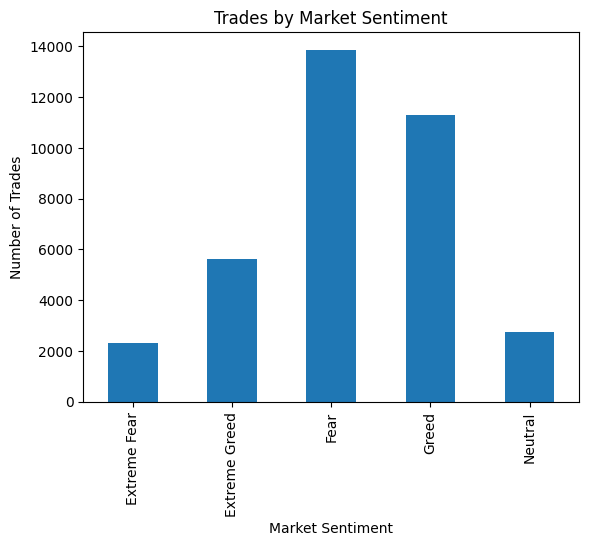

In [48]:
import matplotlib.pyplot as plt

df.groupby('classification').size().plot(kind='bar')

plt.title("Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

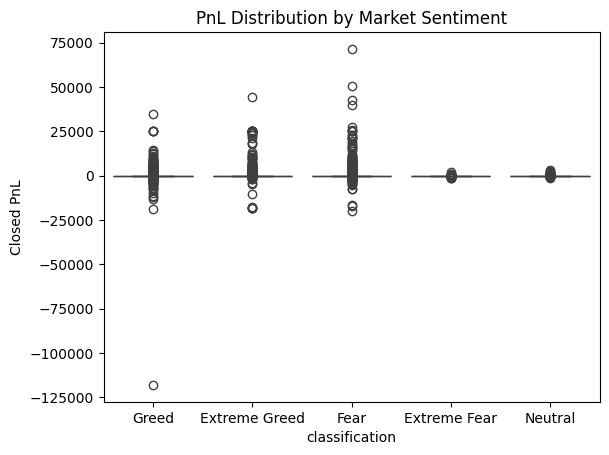

In [49]:
#PnL vs Sentiment Chart
import seaborn as sns

sns.boxplot(x='classification', y='Closed PnL', data=df)

plt.title("PnL Distribution by Market Sentiment")
plt.show()

In [50]:
print("Sentiment missing values")
print(fear_greed_index.isnull().sum())

print("\nTrader missing values")
print(historical_data.isnull().sum())

Sentiment missing values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader missing values
Account                  0
Coin                     0
Execution Price          0
Size Tokens              0
Size USD                 0
Side                     0
Timestamp IST       131999
Start Position           0
Direction                0
Closed PnL               0
Transaction Hash         0
Order ID                 0
Crossed                  0
Fee                      0
Trade ID                 0
Timestamp                0
date                131999
dtype: int64


In [51]:
print("Sentiment duplicates:", fear_greed_index.duplicated().sum())
print("Trader duplicates:", historical_data.duplicated().sum())

Sentiment duplicates: 0
Trader duplicates: 0


Analysis

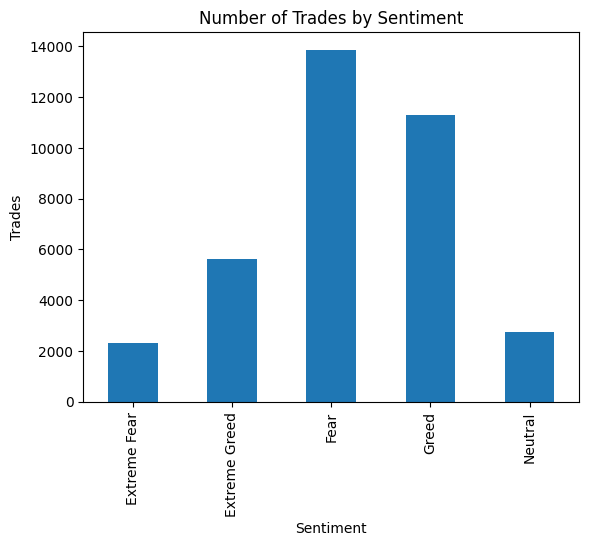

In [52]:
#Trade Frequency vs Sentiment
df.groupby('classification').size().plot(kind='bar')

plt.title("Number of Trades by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trades")
plt.show()

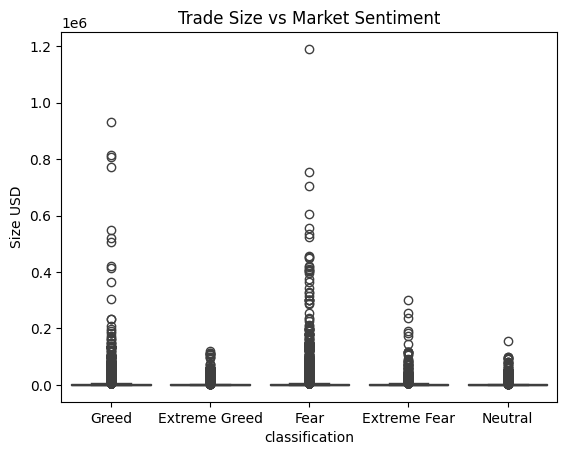

In [53]:
import seaborn as sns

sns.boxplot(x='classification', y='Size USD', data=df)

plt.title("Trade Size vs Market Sentiment")
plt.show()

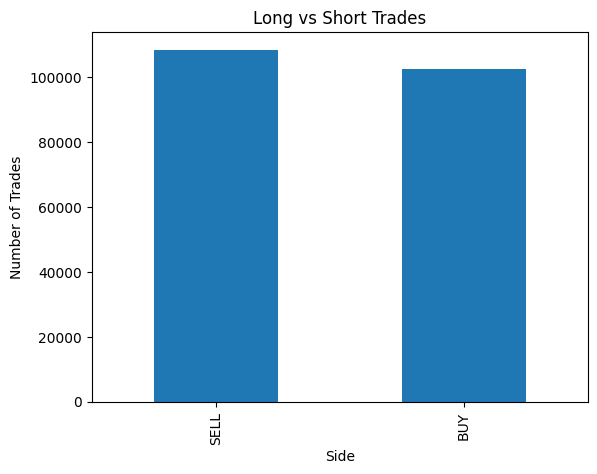

In [54]:
#Long vs Short Analysis
df['Side'].value_counts().plot(kind='bar')

plt.title("Long vs Short Trades")
plt.xlabel("Side")
plt.ylabel("Number of Trades")
plt.show()

Trader Segmentation

In [55]:
trader_pnl = df.groupby('Account')['Closed PnL'].sum()

top_traders = trader_pnl.sort_values(ascending=False).head(10)
top_traders

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


In [56]:
trade_count = df['Account'].value_counts()

frequent_traders = trade_count.head(10)
frequent_traders

,count
Account,
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605
0x8477e447846c758f5a675856001ea72298fd9cb5,14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8519


In [57]:
large_trades = df.groupby('Account')['Size USD'].mean().sort_values(ascending=False).head(10)
large_trades

,Size USD
Account,
0x513b8629fe877bb581bf244e326a047b249c4ff1,34396.580284
0xb899e522b5715391ae1d4f137653e7906c5e2115,22504.555829
0x4f93fead39b70a1824f981a54d4e55b278e9f760,17098.171055
0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,9084.699093
0x271b280974205ca63b716753467d5a371de622ab,8893.000898
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,8330.193371
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,7852.098338
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,7216.667245


**Actionable Insights**

Insight 1: Traders tend to open larger positions during Greed sentiment, indicating increased market confidence.

Insight 2: Trade frequency increases during Greed periods, showing stronger participation during bullish markets.

Insight 3: PnL variability is higher during Fear sentiment, indicating unstable market conditions.

**Strategy Recommendations**

Strategy 1: During Fear sentiment, traders should reduce position size and leverage to limit downside risk.

Strategy 2: During Greed sentiment, traders can increase trade frequency and follow momentum strategies.